# House Price Prediction
Regression pipeline predicting sale price from property features. Compares a Linear Regression
baseline against a Random Forest Regressor, evaluated on RMSE and R².

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

df = pd.read_csv('data/house_prices.csv')
print(df.shape)
df.describe().round(1)

(1500, 8)


,area_sqft,bedrooms,bathrooms,age_years,city_tier,distance_to_city_km,has_garage,sale_price
count,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0
mean,1778.1,3.6,2.7,22.3,2.0,8.1,0.6,3581533.2
std,634.4,1.4,1.1,13.0,0.7,7.9,0.5,1483301.8
min,400.0,1.0,1.0,0.0,1.0,0.2,0.0,355626.0
25%,1328.8,3.0,2.0,11.0,1.0,2.4,0.0,2535996.0
50%,1777.0,4.0,3.0,22.0,2.0,5.8,1.0,3473266.5
75%,2196.0,5.0,3.0,34.0,3.0,11.1,1.0,4460111.0
max,3861.0,6.0,5.0,44.0,3.0,45.0,1.0,9420817.0


## 1. Exploratory look at price drivers

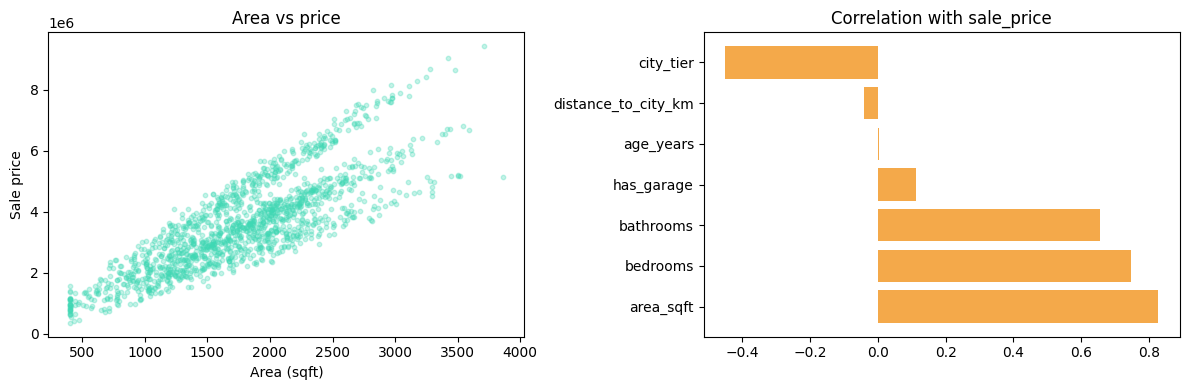

sale_price             1.000000
area_sqft              0.827135
bedrooms               0.746399
bathrooms              0.656027
has_garage             0.112905
age_years              0.004821
distance_to_city_km   -0.039953
city_tier             -0.449527
Name: sale_price, dtype: float64

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].scatter(df['area_sqft'], df['sale_price'], alpha=0.3, s=10, color='#3FD8B4')
axes[0].set_xlabel('Area (sqft)'); axes[0].set_ylabel('Sale price'); axes[0].set_title('Area vs price')

corr = df.corr(numeric_only=True)['sale_price'].sort_values(ascending=False)
axes[1].barh(corr.index[1:], corr.values[1:], color='#F4A94A')
axes[1].set_title('Correlation with sale_price')
plt.tight_layout()
plt.savefig('price_drivers.png', dpi=110)
plt.show()
corr

## 2. Train / test split & feature prep

In [3]:
X = df.drop(columns=['sale_price'])
y = df['sale_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(1200, 7) (300, 7)


## 3. Baseline: Linear Regression

In [4]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)

rmse_lr = mean_squared_error(y_test, pred_lr) ** 0.5
r2_lr = r2_score(y_test, pred_lr)
mae_lr = mean_absolute_error(y_test, pred_lr)
print(f"Linear Regression -> RMSE: {rmse_lr:,.0f}  MAE: {mae_lr:,.0f}  R2: {r2_lr:.3f}")

Linear Regression -> RMSE: 380,779  MAE: 297,847  R2: 0.935


## 4. Random Forest Regressor

In [5]:
rf = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

rmse_rf = mean_squared_error(y_test, pred_rf) ** 0.5
r2_rf = r2_score(y_test, pred_rf)
mae_rf = mean_absolute_error(y_test, pred_rf)
print(f"Random Forest -> RMSE: {rmse_rf:,.0f}  MAE: {mae_rf:,.0f}  R2: {r2_rf:.3f}")

Random Forest -> RMSE: 256,083  MAE: 206,559  R2: 0.971


## 5. Model comparison & feature importance

In [6]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [rmse_lr, rmse_rf],
    'MAE': [mae_lr, mae_rf],
    'R2': [r2_lr, r2_rf],
}).round(3)
results

,Model,RMSE,MAE,R2
0,Linear Regression,380779.238,297847.313,0.935
1,Random Forest,256083.306,206559.278,0.971


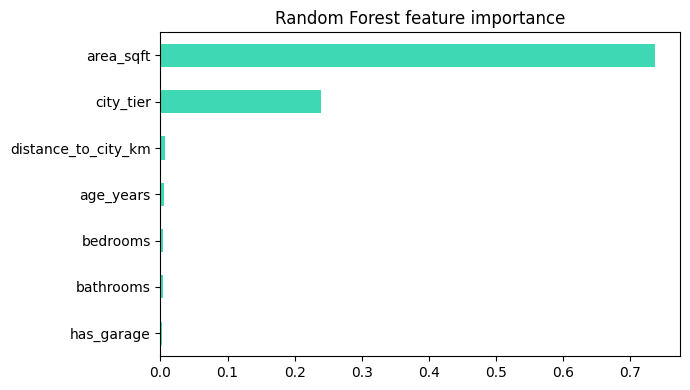

In [7]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(7,4))
importances.plot(kind='barh', color='#3FD8B4')
plt.title('Random Forest feature importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=110)
plt.show()

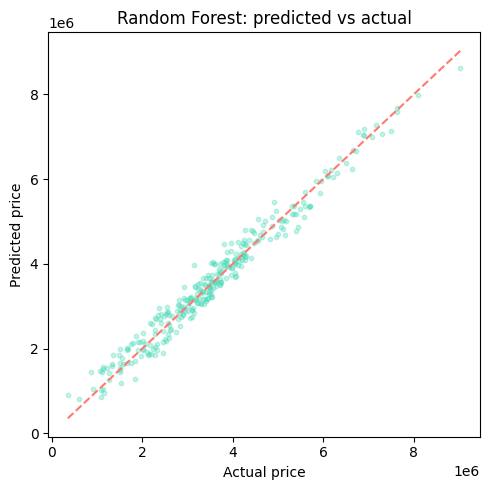

In [8]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, pred_rf, alpha=0.3, s=10, color='#3FD8B4')
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, color='#FF7A6E', linestyle='--')
plt.xlabel('Actual price'); plt.ylabel('Predicted price')
plt.title('Random Forest: predicted vs actual')
plt.tight_layout()
plt.savefig('pred_vs_actual.png', dpi=110)
plt.show()

## Key findings
- Random Forest outperforms the Linear Regression baseline on RMSE, MAE, and R², since price
  isn't a purely linear function of area/bedrooms/distance.
- `area_sqft` and `city_tier` are the strongest price drivers, matching intuition.
- Predicted-vs-actual plot shows the model tracks well across the price range, with the usual
  wider spread at the high end where fewer training examples exist.